In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
df = pd.read_csv("/content/house_price_random_forest_dataset.csv")

print(df.head())
print(df.info())

   Size_sqft  Bedrooms  Bathrooms  Age_of_House  Distance_to_CityCenter_km  \
0       1360         5          2            29                          2   
1       1794         5          3            29                         17   
2       1630         1          1            23                         11   
3       1595         3          1            22                         12   
4       2138         2          2             8                         19   

     House_Price  
0  196690.996352  
1  251830.348251  
2  155396.801553  
3  207270.666870  
4  262850.302515  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Size_sqft                  300 non-null    int64  
 1   Bedrooms                   300 non-null    int64  
 2   Bathrooms                  300 non-null    int64  
 3   Age_of_House               3

In [ ]:
#Define Features & Target

X = df.drop("House_Price", axis=1)
y = df["House_Price"]

In [ ]:
#Train Random Forest Model

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
#Train Random Forest Model

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=6,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=6, random_state=42)

In [ ]:
#Make Predictions

y_pred = rf_model.predict(X_test)

In [ ]:
#Model Evaluation

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", round(mse, 2))
print("R2 Score:", round(r2, 4))

Mean Squared Error: 854789840.3
R2 Score: 0.9305


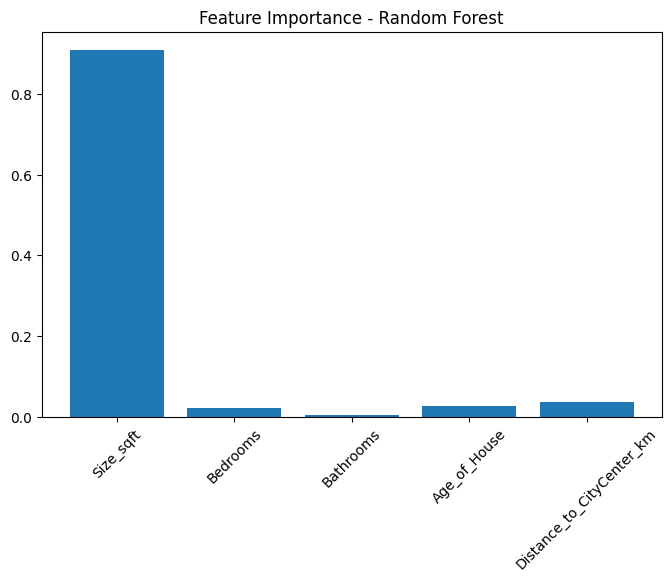

In [ ]:
#Feature Importance Plot

importances = rf_model.feature_importances_
features = X.columns

plt.figure(figsize=(8,5))
plt.bar(features, importances)
plt.title("Feature Importance - Random Forest")
plt.xticks(rotation=45)
plt.show()

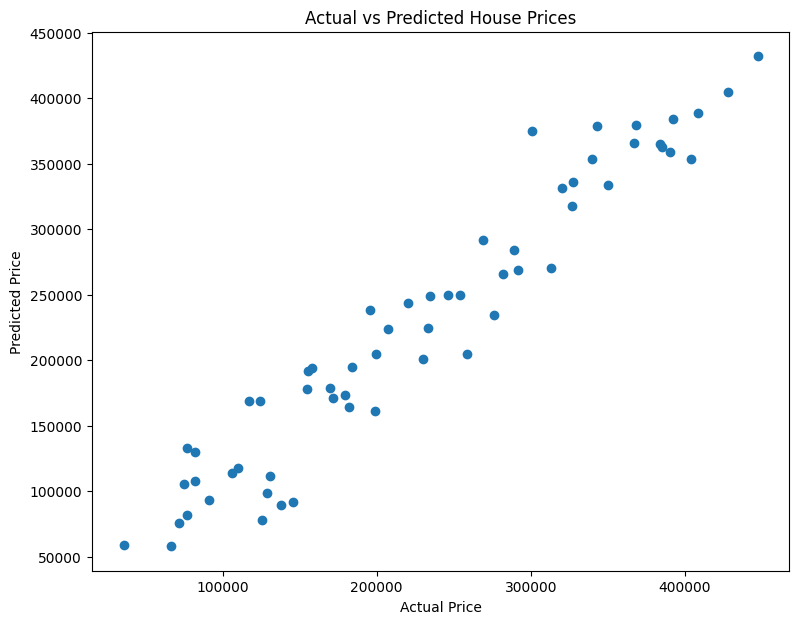

In [ ]:
#Prediction vs Actual Plot

plt.figure(figsize=(9,7))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()